In [21]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [22]:
X,y = make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20)

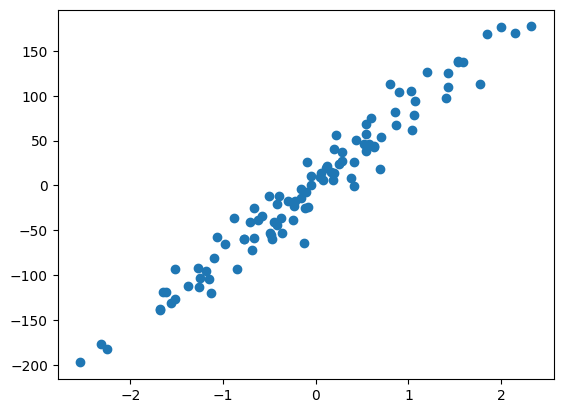

In [23]:
plt.scatter(X,y)

In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=2)

In [25]:
from sklearn.linear_model import LinearRegression
le= LinearRegression()
le.fit(X_train,y_train)

print(le.coef_)
print(le.intercept_)

[80.89878944]
2.068395011604987


In [ ]:
y_pred = le.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.9743169384428766

In [27]:
class GDRegressor :
    def __init__(self,learning_rate,epochs):
        self.m= 100
        self.b = 120
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,X,y):
        # calculating b,m using gradient descent
        for i in range(self.epochs):
            # find derivative for b
            loss_slope_b= -2 * np.sum(y - self.m*X.ravel() -self.b)
            self.b = self.b - (self.lr * loss_slope_b)
            # find derivative for m
            loss_slope_m= -2 * np.sum((y - self.m*X.ravel() -self.b) * X.ravel())
            self.m = self.m - (self.lr * loss_slope_m)
        print(self.m,self.b)

    def predict(self,X):
        return self.m * X +self.b

In [28]:
gd = GDRegressor(0.001,50)

In [29]:
gd.fit(X_train,y_train)

80.89217569276691 2.0885865320633754


In [30]:
y_pred = gd.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.9743341016276283